<a href="https://colab.research.google.com/github/hariprasath0000/-assignment-01-applied-deep-learning/blob/main/10.Pytorch%20AutoEncoder%20Neural%20Network%20for%20Image%20Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# torch loaded...!!!
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# torchvision loaded...!!!
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torchsummary import summary

# matplotlib loaded...!!!
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from tqdm import tqdm

### **2.Define Constants**

In [2]:
# Constants
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
BATCH_SIZE = 32
NOISE_FACTOR = 0.5 # constant NOISE_FACTOR which defines the amount of noise that we will add to our images.

### **3.Prepare the Data**

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, ), std=(0.5, ))
])

### **4.Data Loader and Download**

In [4]:
# Download the FashionMNIST dataset
trainset = torchvision.datasets.FashionMNIST(root='./data_new', train = True, download= True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data_new', train = False, download= True, transform=transform)

# Load the dataset in the dataloader
trainLoader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testLoader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)



100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.1MB/s]


In [5]:
for batch in trainLoader:
    batch1 = batch
    break

batch1[0].shape, batch[1].shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

### **5.Some Helper Function**

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def make_dir():
    image_dir = 'Saved_Images'
    if not os.path.exists(image_dir):
        os.mkdir(image_dir)

def save_decoded_image(img, name):
    img = img.view(img.size(0), 1, 28, 28)
    save_image(img, 'Saved_Images/' + name + '.png')

### **6.Define the AutoEncoder Neural Network**

In [7]:
class AutorEncoder(nn.Module):
    def __init__(self):
        super(AutorEncoder, self).__init__()

        # Encoder layers
        self.enc1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.enc3 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.enc4 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        # Decoder layers
        self.dec1 = nn.ConvTranspose2d(8, 8, kernel_size=3, stride=2)
        self.dec2 = nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2)
        self.dec3 = nn.ConvTranspose2d(16, 32, kernel_size=2, stride=2)
        self.dec4 = nn.ConvTranspose2d(32, 64, kernel_size=2, stride=2)
        self.out = nn.Conv2d(64, 1, kernel_size=3, padding=1)


    def forward(self, x):
        # Encoder
        x = self.pool(F.relu(self.enc1(x)))
        x = self.pool(F.relu(self.enc2(x)))
        x = self.pool(F.relu(self.enc3(x)))
        x = self.pool(F.relu(self.enc4(x))) # latent space representation

        # Decoder
        x = F.relu(self.dec1(x))
        x = F.relu(self.dec2(x))
        x = F.relu(self.dec3(x))
        x = F.relu(self.dec4(x))
        x = torch.sigmoid(self.out(x))

        return x

model = AutorEncoder().to(device)

In [8]:
print(model)

AutorEncoder(
  (enc1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc4): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dec1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2))
  (dec2): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (dec3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (dec4): ConvTranspose2d(32, 64, kernel_size=(2, 2), stride=(2, 2))
  (out): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [9]:
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
         MaxPool2d-2           [-1, 64, 14, 14]               0
            Conv2d-3           [-1, 32, 14, 14]          18,464
         MaxPool2d-4             [-1, 32, 7, 7]               0
            Conv2d-5             [-1, 16, 7, 7]           4,624
         MaxPool2d-6             [-1, 16, 3, 3]               0
            Conv2d-7              [-1, 8, 3, 3]           1,160
         MaxPool2d-8              [-1, 8, 1, 1]               0
   ConvTranspose2d-9              [-1, 8, 3, 3]             584
  ConvTranspose2d-10             [-1, 16, 7, 7]           1,168
  ConvTranspose2d-11           [-1, 32, 14, 14]           2,080
  ConvTranspose2d-12           [-1, 64, 28, 28]           8,256
           Conv2d-13            [-1, 1, 28, 28]             577
Total params: 37,553
Trainable params: 

### **7. Optimizer and Loss Function**

In [10]:
# the loss function
loss_fn = nn.MSELoss()
# the optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### **8.Defining the training and test function**

In [11]:
def train(net, trainLoader, NUM_EPOCHS):
    train_loss = []
    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        with tqdm(trainLoader, unit="batch") as tepoch:
            for data in tepoch:
                tepoch.set_description(f"Epoch {epoch+1}")
                img, _ = data # we do not need the image labels
                # add noise to the image data
                img_noisy = img + NOISE_FACTOR * torch.randn(img.shape)
                # clip to make the values fall between 0 and 1
                img_noisy = np.clip(img_noisy, 0., 1.)
                img_noisy = img_noisy.to(device)
                optimizer.zero_grad()
                outputs = net(img_noisy)
                loss = loss_fn(outputs, img_noisy)
                # backpropagation
                loss.backward()
                # update the parameters
                optimizer.step()
                running_loss += loss.item()
                tepoch.set_postfix(loss=loss)

            loss = running_loss / len(trainLoader)
            train_loss.append(loss)
            # print(f"Epoch {epoch} loss: {loss}")
            save_decoded_image(img_noisy.cpu().data, name='noisy{}'.format(epoch))
            save_decoded_image(outputs.cpu().data, name='denoised{}'.format(epoch))

    return train_loss


def test_image_reconstruction(net, testloader):
     for batch in testloader:
        img, _ = batch
        img_noisy = img + NOISE_FACTOR * torch.randn(img.shape)
        img_noisy = np.clip(img_noisy, 0., 1.)
        img_noisy = img_noisy.to(device)
        outputs = net(img_noisy)
        outputs = outputs.view(outputs.size(0), 1, 28, 28).cpu().data
        save_image(img_noisy, 'noisy_test_input.png')
        save_image(outputs, 'denoised_test_reconstruction.png')
        break

### **9.Model Training and Result Analysis**

Epoch 10: 100%|██████████| 1875/1875 [05:32<00:00,  5.63batch/s, loss=tensor(0.0571, grad_fn=<MseLossBackward0>)]


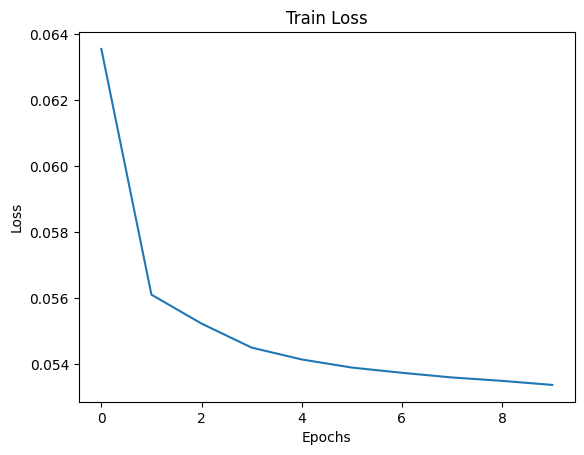

In [12]:
make_dir()
train_loss = train(model, trainLoader, NUM_EPOCHS)
plt.figure()
plt.plot(train_loss)
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig('./Saved_Images/conv_ae_fahsionmnist_loss.png')
test_image_reconstruction(model, testLoader)

In [14]:
min_loss = min(train_loss)
min_loss_epoch = train_loss.index(min_loss) + 1 # +1 because epochs are 1-indexed for display
print(f"The epoch with the lowest loss is Epoch {min_loss_epoch} with a loss of {min_loss:.4f}")

The epoch with the lowest loss is Epoch 10 with a loss of 0.0534


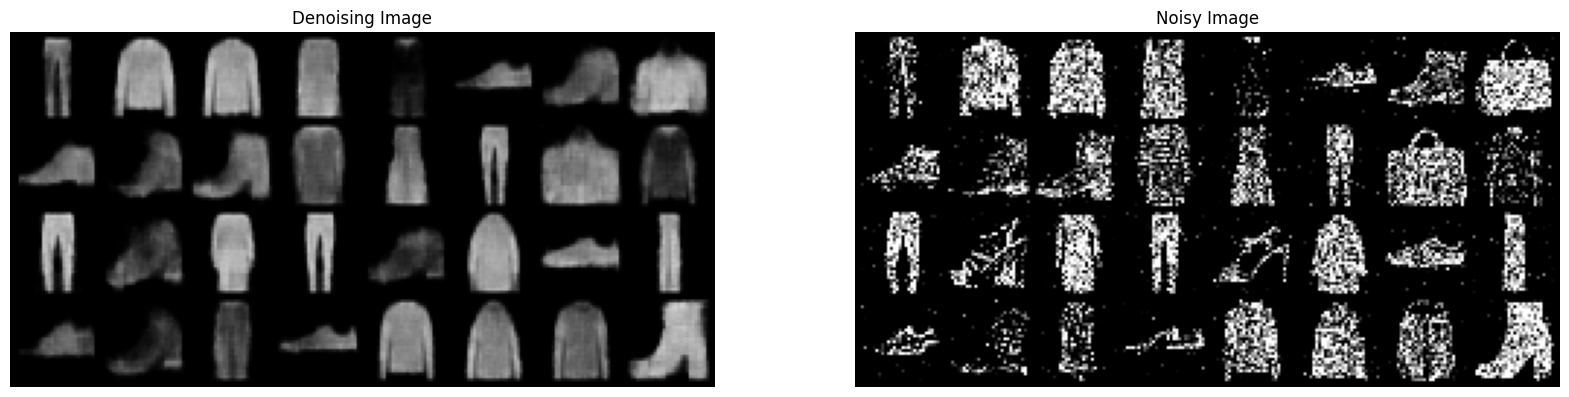

In [16]:
import matplotlib.image as mpimg
import os # Import os module to handle paths better

plt.figure(figsize=(20,20))

# Construct the correct paths for the images
image_dir = 'Saved_Images'
img_denoised_path = os.path.join(image_dir, 'denoised9.png')
img_noisy_path = os.path.join(image_dir, 'noisy9.png')

img = mpimg.imread(img_denoised_path)
img1 = mpimg.imread(img_noisy_path)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Denoising Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img1)
plt.title('Noisy Image')
plt.axis('off')
plt.show()